<a href="https://colab.research.google.com/github/Comfy05/Football_analytics_portfolio/blob/main/passing_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mplsoccer
!pip install statsbombpy

In [ ]:
from pandas.core.arrays import period
import pandas as pd
from statsbombpy import sb
from mplsoccer import Pitch, VerticalPitch
from matplotlib.pyplot import scatter
import matplotlib.pyplot as plt

competitions = sb.competitions()

event = sb.events(match_id=3869152)
event = event[event['period'] == 1]

passing = event['type'] == 'Pass'
event_passing = event[passing][['player','location','team','minute','pass_outcome', 'pass_recipient']]
event_passing.head()

good_pass = event_passing['pass_outcome'].isnull()
event_passing = event_passing[good_pass]

event_passing = event_passing.join(pd.DataFrame(event_passing.pop('location').tolist(), index = event_passing.index, columns=["x", 'y']))
event_passing.head()
#pass_outcome = Nan to znaczy że jest git

,player,team,minute,pass_outcome,pass_recipient,x,y
6,Olivier Giroud,France,0,NaN,Aurélien Djani Tchouaméni,60.0,40.0
7,Aurélien Djani Tchouaméni,France,0,NaN,Jules Koundé,48.7,42.1
8,Jules Koundé,France,0,NaN,Hugo Lloris,41.8,64.4
10,Adrien Rabiot,France,0,NaN,Antoine Griezmann,72.0,32.1
13,Adrien Rabiot,France,1,NaN,Olivier Giroud,55.9,20.7


In [ ]:
#podział na dwie tabele zwiazane z druzynami

polska = event_passing["team"] == "Poland"
france = event_passing["team"] == "France"
passing_polska = event_passing[polska]
passing_france = event_passing[france]

In [ ]:
france_mean_position = passing_france.groupby('player')[['x','y']].mean()
pass_count_france = passing_france.groupby(['player', 'pass_recipient']).size().rename('pass_count').reset_index()

france_merged_pre_version = pd.merge(france_mean_position, pass_count_france, how='inner', on=['player'])
france_merged_pre_version = france_merged_pre_version.rename(columns={'x':'x_start', 'y':'y_start'})

france_merged = pd.merge(france_merged_pre_version, france_mean_position, how='inner', left_on='pass_recipient', right_index=True).rename(columns={'x':'x_end','y':'y_end'})

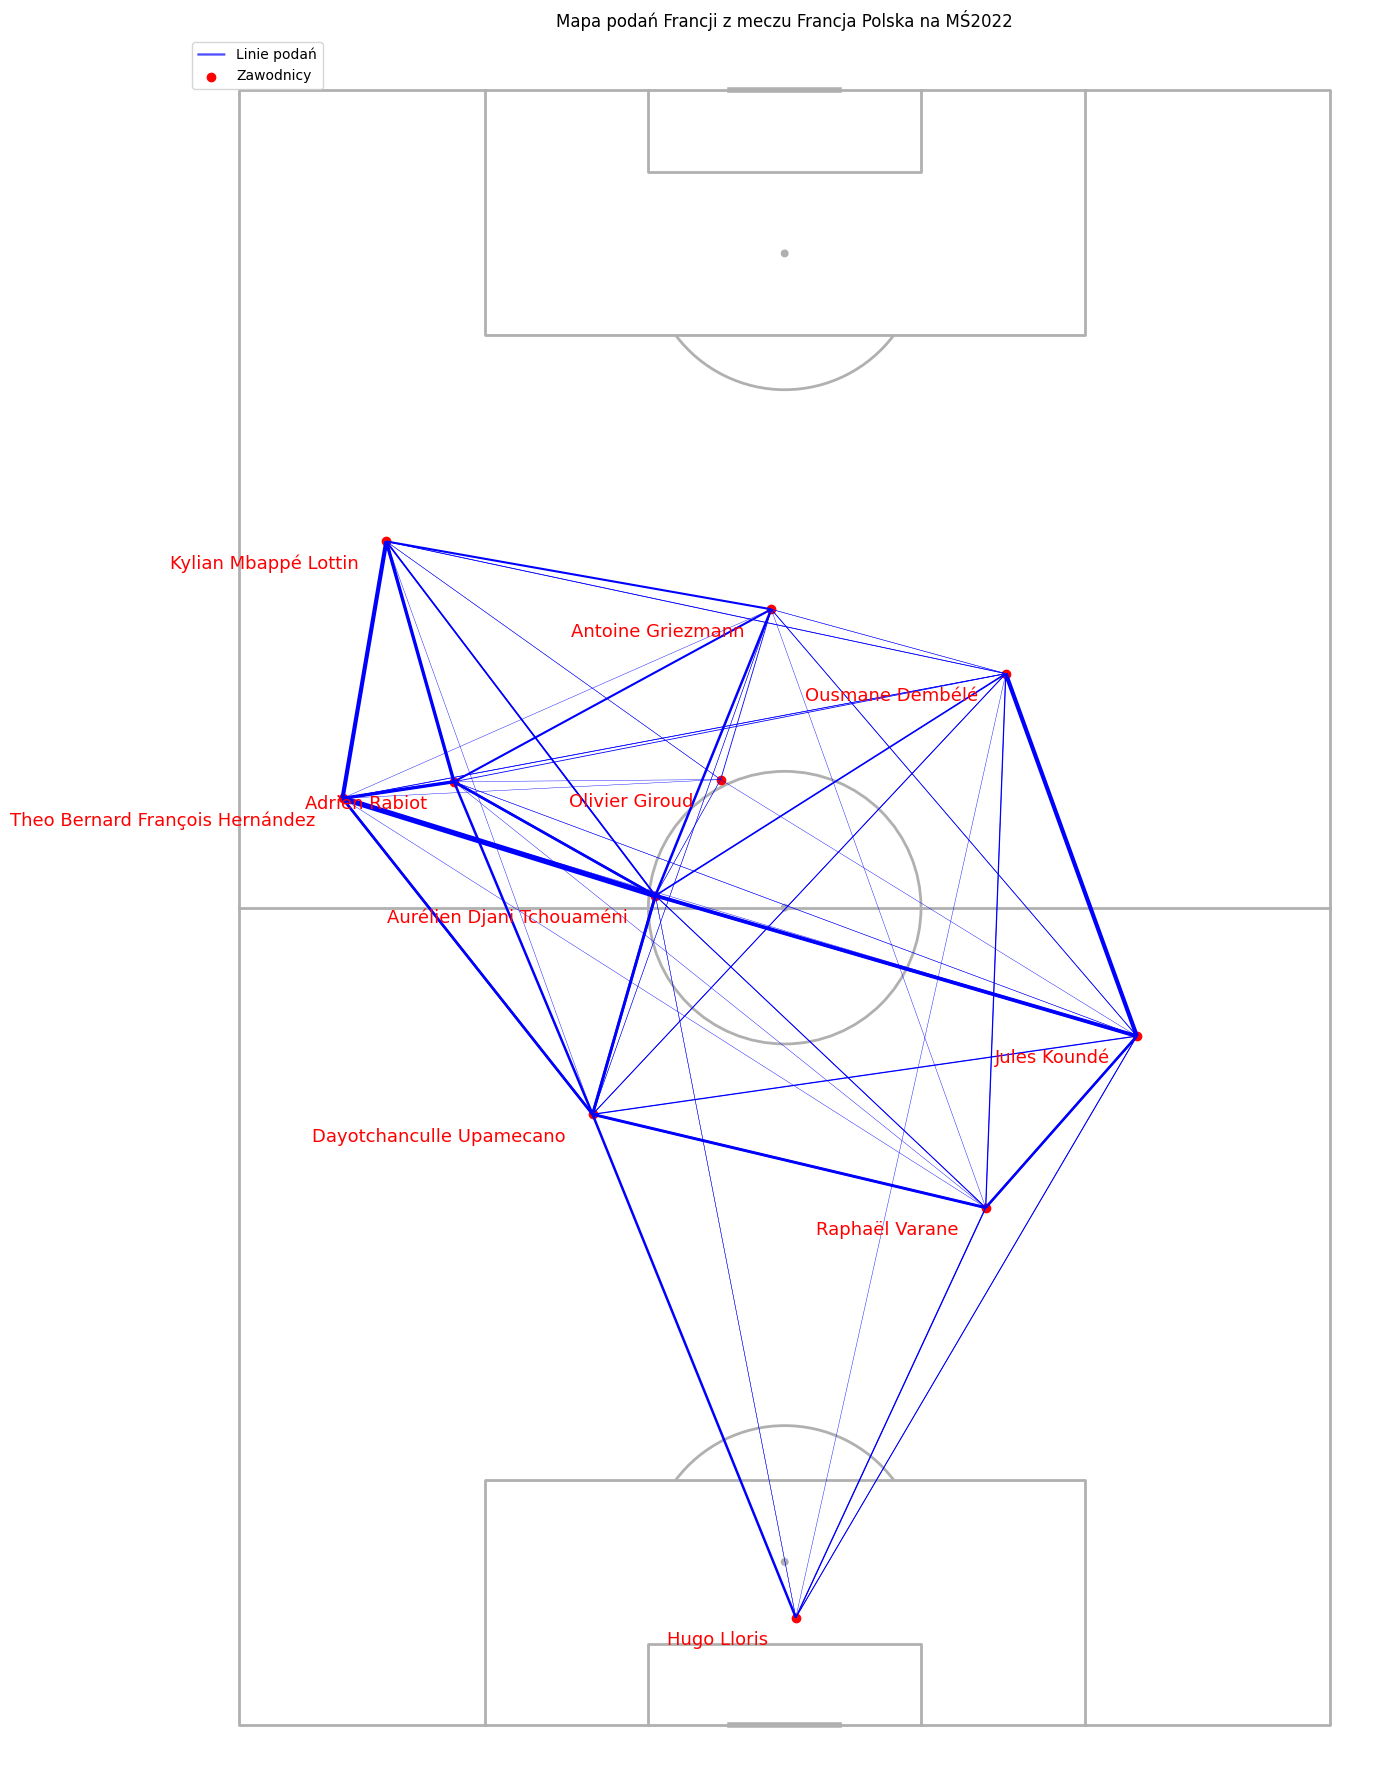

In [ ]:
pitch = VerticalPitch(pitch_type='statsbomb')
fig, ax = pitch.draw(figsize = (14,18))

pitch.lines(xstart=france_merged['x_start'], ystart=france_merged['y_start'], xend=france_merged['x_end'], yend=france_merged['y_end'], color='blue', linewidth=france_merged['pass_count']*0.3 ,ax=ax, label = "Linie podań")
pitch.scatter(x=france_mean_position['x'], y=france_mean_position['y'], color='red', ax=ax, label="Zawodnicy")

for index, row in france_mean_position.iterrows():
  pitch.annotate(index, (row['x'], row['y']), xytext=(row['x'] - 2, row['y'] - 2), textcoords='data', fontsize=13, color='red', ha='right', ax=ax)

ax.set_title('Mapa podań Francji z meczu Francja Polska na MŚ2022')
ax.legend(loc='upper left')
plt.savefig('map_of_passes_francja_polska_first_half_francja.pdf')

In [ ]:
polska_mean_position = passing_polska.groupby('player')[['x','y']].mean()
pass_count_polska = passing_polska.groupby(['player', 'pass_recipient']).size().rename('pass_count').reset_index()

polska_merged_pre_version = pd.merge(polska_mean_position, pass_count_polska, how='inner', on=['player'])
polska_merged_pre_version = polska_merged_pre_version.rename(columns={'x':'x_start', 'y':'y_start'})

polska_merged = pd.merge(polska_merged_pre_version, polska_mean_position, how='inner', left_on='pass_recipient', right_index=True).rename(columns={'x':'x_end','y':'y_end'})

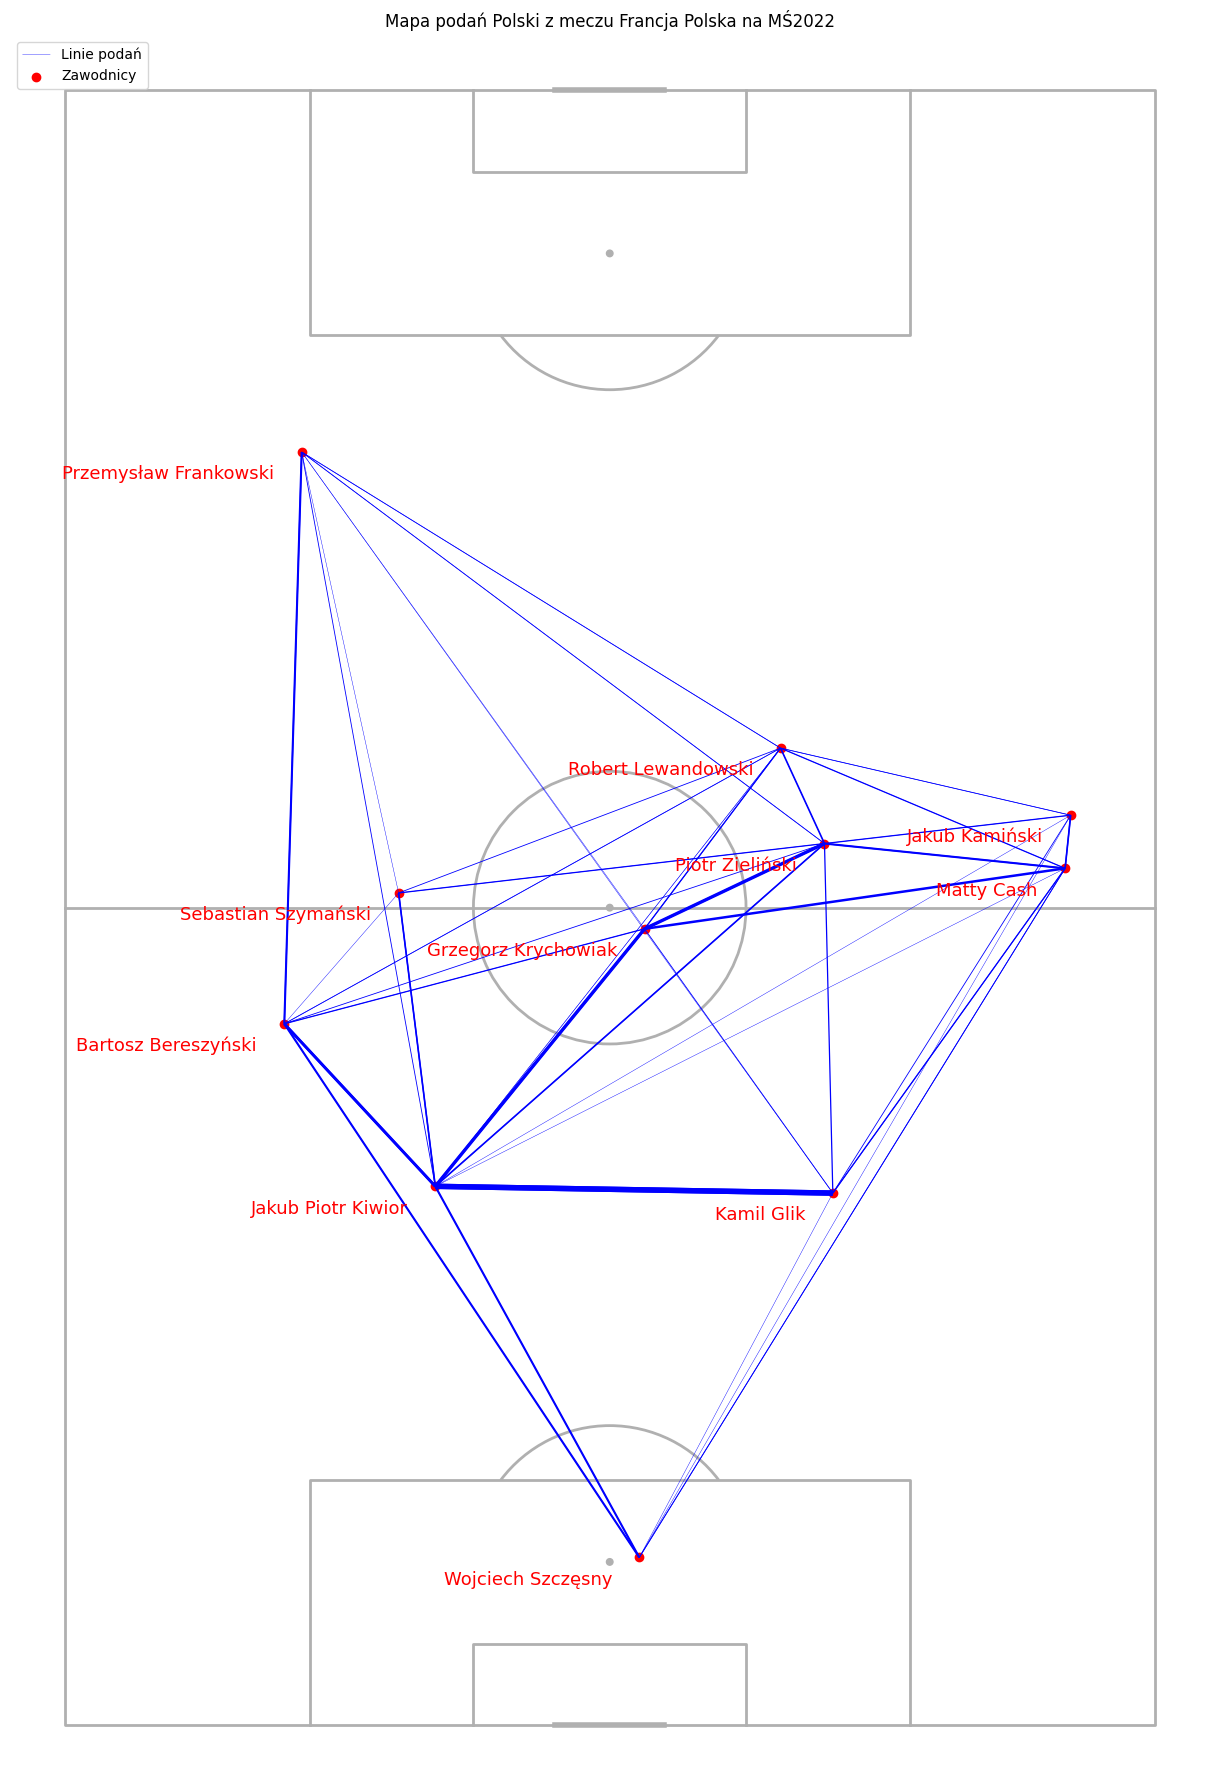

In [ ]:
pitch = VerticalPitch(pitch_type='statsbomb')
fig, ax = pitch.draw(figsize = (14,18))

pitch.lines(xstart=polska_merged['x_start'], ystart=polska_merged['y_start'], xend=polska_merged['x_end'], yend=polska_merged['y_end'], color='blue', linewidth=polska_merged['pass_count']*0.3 ,ax=ax, label = "Linie podań")
pitch.scatter(x=polska_mean_position['x'], y=polska_mean_position['y'], color='red', ax=ax, label="Zawodnicy")

for index, row in polska_mean_position.iterrows():
  pitch.annotate(index, (row['x'], row['y']), xytext=(row['x'] - 2, row['y'] - 2), textcoords='data', fontsize=13, color='red', ha='right', ax=ax)

ax.set_title('Mapa podań Polski z meczu Francja Polska na MŚ2022')
ax.legend(loc='upper left')
plt.savefig('map_of_passes_francja_polska_first_half_polska.pdf')